## 3. Feature Engineering

> **Context from EDA/Preprocessing:**  
> - Missing values filled via structural 0-fill (student vs professional split columns).  
> - Outliers retained.  
> - **Robust Scaler** chosen based on Levene's Test analysis.  
> - Perfect multicollinearity (r = ±1.0) between `Academic Pressure`/`Work Pressure` and `Study Satisfaction`/`Job Satisfaction`.  
> - `Sleep Duration` 36 dirty uniques, `Dietary Habits` 23, `Degree` 115.

> **Anti-leakage rule:** Every encoder map, category list, and scaler is **fit on train only** then applied to test mechanically.

In [1]:
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Paths 
DATA_DIR     = Path("../data/processed/")
ARTIFACT_DIR = Path("../artifacts/")   # scalers / encoder maps saved here
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_IN  = DATA_DIR / "train.csv"
TEST_IN = DATA_DIR / "valid.csv"
TRAIN_OUT = DATA_DIR / "fe_train.csv"
TEST_OUT  = DATA_DIR / "fe_valid.csv"

# Load 
train = pd.read_csv(TRAIN_IN)
test  = pd.read_csv(TEST_IN)

print("Train:", train.shape, "  Test:", test.shape)
train.head(3)

Train: (112552, 18)   Test: (28138, 18)


,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,52.0,Chennai,Working Professional,HR Manager,0.0,5.0,0.0,0.0,3.0,More than 8 hours,Unhealthy,ME,Yes,4.0,4.0,No,0
1,Female,45.0,Jaipur,Working Professional,Civil Engineer,0.0,4.0,0.0,0.0,4.0,More than 8 hours,Moderate,B.Tech,No,8.0,4.0,No,0
2,Male,38.0,Bangalore,Working Professional,Financial Analyst,0.0,3.0,0.0,0.0,2.0,5-6 hours,Moderate,B.Com,Yes,1.0,1.0,No,0


---
### 3.1 Text Normalization (Pre-Encoding Cleanup)

During EDA, we observed high cardinality and messy formatting in Sleep Duration (36 unique values), Dietary Habits (23), and Degree (115). Leaving these as-is would result in hundreds of meaningless one-hot encoded columns (the Curse of Dimensionality) and introduce noise. We use domain-based Regex mapping to group these into canonical categories. Because this is purely logic-based and doesn't rely on dataset statistics, it introduces no data leakage.

In [2]:
# 3.1a  Sleep Duration -> 4 canonical categories
train_df_before = train.copy()
def normalise_sleep(value):
    """Map free-text sleep duration to one of 4 canonical buckets."""
    if pd.isna(value):
        return "Other"
    v = str(value).strip().lower()
    if re.search(r"less|<\s*5|under\s*5|below\s*5", v):
        return "Less than 5h"
    if re.search(r"5[-\u20135\s]6|5 to 6", v):
        return "5-6h"
    if re.search(r"7[-\u20138\s]8|7 to 8", v):
        return "7-8h"
    if re.search(r"more|>\s*8|above\s*8|over\s*8|\b9\b|\b10\b|\b11\b|\b12\b", v):
        return "More than 8h"
    return "Other"

for df in [train, test]:
    df["Sleep Duration"] = df["Sleep Duration"].apply(normalise_sleep)

print("Sleep Duration — train value counts after normalisation:")
print(train["Sleep Duration"].value_counts())

Sleep Duration — train value counts after normalisation:
Sleep Duration
Less than 5h    31088
7-8h            29691
More than 8h    26105
5-6h            25613
Other              55
Name: count, dtype: int64


In [3]:
# 3.1b  Dietary Habits -> 3 canonical categories

def normalise_diet(value):
    if pd.isna(value):
        return "Moderate"
    v = str(value).strip().lower()
    if re.search(r"unhealthy|poor|bad|junk", v):
        return "Unhealthy"
    if re.search(r"health", v):  # catches healthy, very healthy, etc.
        return "Healthy"
    return "Moderate"  # absorbs typos and ambiguous entries

for df in [train, test]:
    df["Dietary Habits"] = df["Dietary Habits"].apply(normalise_diet)

print("Dietary Habits — train value counts after normalisation:")
print(train["Dietary Habits"].value_counts())

Dietary Habits — train value counts after normalisation:
Dietary Habits
Moderate     39720
Unhealthy    37068
Healthy      35764
Name: count, dtype: int64


In [4]:
# 3.1c  Degree -> 4 ordered education levels
def normalise_degree(value):
    if pd.isna(value):
        return "Bachelor"  # most-frequent safe default
    v = str(value).strip().lower()
    if re.search(r"phd|ph\.d|doctorate|doctoral", v):
        return "PhD"
    if re.search(
        r"^m\.|\.mtech|\bmba\b|\.msc|\bm\.a\b|\.mpharm|\.med|\.march|\bmaster",
        v):
        return "Master"
    if re.search(r"class 12|12th|hsc|high school|higher secondary|intermediate", v):
        return "High School"
    return "Bachelor"  # covers all B. prefixed degrees + unrecognised

for df in [train, test]:
    df["Degree"] = df["Degree"].apply(normalise_degree)

print("Degree — train value counts after normalisation:")
print(train["Degree"].value_counts())

Degree — train value counts after normalisation:
Degree
Bachelor       80912
Master         17288
High School    11870
PhD             2482
Name: count, dtype: int64


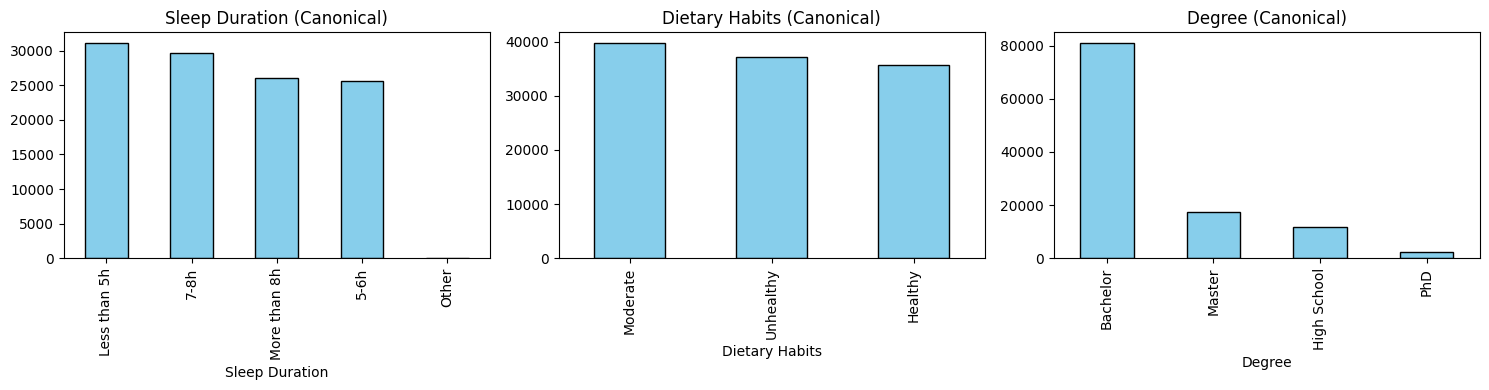

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
cols = ['Sleep Duration', 'Dietary Habits', 'Degree']
for i, col in enumerate(cols):
    train[col].value_counts().plot(kind='bar', ax=ax[i], color='skyblue', edgecolor='black')
    ax[i].set_title(f"{col} (Canonical)")
plt.tight_layout()
plt.show()

In [6]:
def summary_unique_values(df_old, df_new, columns):
    stats = []
    for col in columns:
        if col in df_old.columns and col in df_new.columns:
            unq_before = df_old[col].nunique()
            unq_after = df_new[col].nunique()
            reduction = unq_before - unq_after
            
            stats.append({
                "Feature": col,
                "Unique (Before)": unq_before,
                "Unique (After)": unq_after,
                "Reduction": reduction,
                "% Reduction": f"{(reduction/unq_before)*100:.1f}%" if unq_before > 0 else "0%"
            })
    
    df_stats = pd.DataFrame(stats)
    print("Compare unique value counts before and after normalization")
    return df_stats

summary_unique_values(train_df_before, train, cols)

Compare unique value counts before and after normalization


,Feature,Unique (Before),Unique (After),Reduction,% Reduction
0,Sleep Duration,34,5,29,85.3%
1,Dietary Habits,20,3,17,85.0%
2,Degree,104,4,100,96.2%


---
### 3.2 Feature Merging

In the EDA phase, Pearson correlation analysis revealed perfect multicollinearity ($r = \pm1.0$) between Academic Pressure and Work Pressure, as well as Study Satisfaction and Job Satisfaction. This occurs because students and working professionals are mutually exclusive groups. To resolve this without losing information, we merge them into unified Pressure and Satisfaction variables and drop the original columns. This prevents unstable weights in linear models.

In [7]:
for df in [train, test]:
    df["Pressure"]     = df["Academic Pressure"] + df["Work Pressure"]
    df["Satisfaction"] = df["Study Satisfaction"] + df["Job Satisfaction"]
    df.drop(
        columns=["Academic Pressure", "Work Pressure",
                 "Study Satisfaction", "Job Satisfaction"],
        inplace=True)

# CGPA: keep — 0-fill already done in preprocessing.
# 0 acts as "not applicable" for professionals; tree models can exploit this.
# "Working Professional or Student" already captures group identity.

print("Columns after merge:")
print(train.columns.tolist())

Columns after merge:
['Gender', 'Age', 'City', 'Working Professional or Student', 'Profession', 'CGPA', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression', 'Pressure', 'Satisfaction']


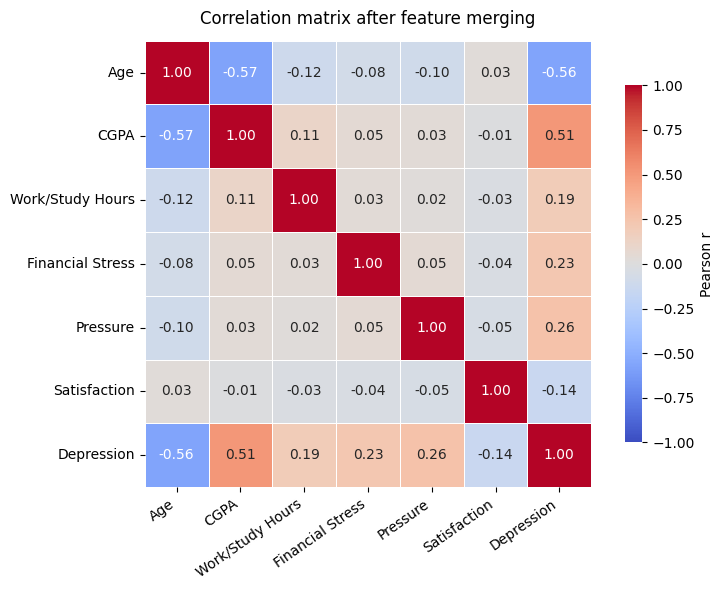


Top absolute correlations with Depression:
Age                 0.564358
CGPA                0.510436
Pressure            0.261965
Financial Stress    0.229169
Work/Study Hours    0.191059
Satisfaction        0.144065
Name: Depression, dtype: float64


In [8]:
# 3.2.1 Correlation heatmap after feature merging
numeric_cols = ["Age", "CGPA", "Work/Study Hours", "Financial Stress",
                "Pressure", "Satisfaction", "Depression"]

corr_post_merge = train[numeric_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_post_merge,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    ax=ax,
)
ax.set_title("Correlation matrix after feature merging", fontsize=12, pad=12)
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nTop absolute correlations with Depression:")
print(
    corr_post_merge["Depression"]
    .drop("Depression")
    .abs()
    .sort_values(ascending=False)
)

---
### 3.3 Composite Features (Domain-Driven)

To help tree-based models capture non-linear interactions, we engineered two composite features based on domain logic:

1. Stress_Score: The sum of Pressure and Financial Stress, representing the total psychological burden.

2. Sleep_Risk_Flag: A binary indicator for sleeping less than 5 hours, a known clinical risk factor for depression.

In [9]:
for df in [train, test]:
    # Total psychological burden across two orthogonal stress dimensions
    df["Stress_Score"] = df["Pressure"] + df["Financial Stress"]
    
    # Drop components to avoid multicollinearity since Stress_Score is a linear combination
    df.drop(columns=["Pressure", "Financial Stress"], inplace=True)

    # Clinical marker: sleep < 5h strongly linked to depression risk.
    # Applied AFTER normalise_sleep, so 'Less than 5h' is already canonical.
    df["Sleep_Risk_Flag"] = (df["Sleep Duration"] == "Less than 5h").astype(int)

print("Composite features preview:")
train[["Stress_Score", "Sleep Duration", "Sleep_Risk_Flag"]].head()

Composite features preview:


,Stress_Score,Sleep Duration,Sleep_Risk_Flag
0,9.0,More than 8h,0
1,8.0,More than 8h,0
2,4.0,5-6h,0
3,7.0,7-8h,0
4,5.0,Less than 5h,1


---
### 3.4 Encoding

All encoding maps and category lists are **derived from train only** then applied to test.

In [10]:
# 3.4a  Binary Encoding
shape_history = [("0. Before encoding (after FE)", train.shape[0], train.shape[1], "—")]

BINARY_MAPS = {
    "Gender":                                {"Male": 1, "Female": 0},
    "Working Professional or Student":       {"Working Professional": 1, "Student": 0},
    "Have you ever had suicidal thoughts ?": {"Yes": 1, "No": 0},
    "Family History of Mental Illness":      {"Yes": 1, "No": 0},
}

RENAME_MAP = {
    "Have you ever had suicidal thoughts ?": "Suicidal_Thoughts",
    "Working Professional or Student":       "Is_Working_Professional",
}

for df in [train, test]:
    for col, mapping in BINARY_MAPS.items():
        df[col] = df[col].map(mapping)
    df.rename(columns=RENAME_MAP, inplace=True)

# Surface unexpected NaN introduced by values outside the binary map
for col in list(RENAME_MAP.values()) + ["Gender", "Family History of Mental Illness"]:
    n = train[col].isnull().sum()
    if n:
        print(f"WARNING: {n} NaN in {col} after binary encoding — check source values")
shape_history.append(("1. After Binary Encoding", train.shape[0], train.shape[1],
                      f"{len(BINARY_MAPS)} binary columns -> 0/1"))
print("Binary encoding done. Sample:")
train[["Gender", "Is_Working_Professional",
       "Suicidal_Thoughts", "Family History of Mental Illness"]].head(3)


Binary encoding done. Sample:


,Gender,Is_Working_Professional,Suicidal_Thoughts,Family History of Mental Illness
0,0,1,1,0
1,0,1,0,0
2,1,1,1,0


In [11]:
# 3.4b  Ordinal Encoding
# Maps encode natural order — not derived from train statistics.
# "Other" in Sleep Duration falls back to 2 (median bucket).

ORDINAL_MAPS = {
    "Sleep Duration": {
        "Less than 5h": 1,
        "5-6h":         2,
        "7-8h":         3,
        "More than 8h": 4,
        "Other":        2,  # median fallback
    },
    "Dietary Habits": {
        "Unhealthy": 1,
        "Moderate":  2,
        "Healthy":   3,
    },
    "Degree": {
        "High School": 1,
        "Bachelor":    2,
        "Master":      3,
        "PhD":         4,
    },
}

joblib.dump(ORDINAL_MAPS, ARTIFACT_DIR / "ordinal_maps.pkl")

for df in [train, test]:
    for col, mapping in ORDINAL_MAPS.items():
        df[col] = df[col].map(mapping)

shape_history.append(("2. After Ordinal Encoding", train.shape[0], train.shape[1],
                      f"{len(ORDINAL_MAPS)} ordinal columns -> integers"))
print("Ordinal columns after encoding:")
for col in ORDINAL_MAPS:
    print(f"  {col}: {sorted(train[col].dropna().unique())}")

Ordinal columns after encoding:
  Sleep Duration: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  Dietary Habits: [np.int64(1), np.int64(2), np.int64(3)]
  Degree: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


We apply One-Hot Encoding only to the most frequent categories to prevent feature explosion. `City` is limited to the top 15 and `Profession` to the top 10. All unseen or less frequent values in both Train and Test sets are grouped into an 'Other' bucket.

In [12]:
# 3.4c  High-Cardinality One-Hot Encoding
#   top-N lists computed on TRAIN only.
#   Test values outside that list are binned to "Other".
#   Test dummy columns reindexed to exactly match train (fill 0 for unseen).

def top_n_ohe(train_df, test_df, col, n, prefix):
    """Fit top-N on train, bin both splits, OHE, align columns, drop Other dummy."""
    top_cats = train_df[col].value_counts().nlargest(n).index.tolist()

    for df in [train_df, test_df]:
        df[col] = df[col].where(df[col].isin(top_cats), other="Other")

    train_d = pd.get_dummies(train_df[col], prefix=prefix, drop_first=False, dtype=int)
    test_d  = pd.get_dummies(test_df[col],  prefix=prefix, drop_first=False, dtype=int)
    test_d  = test_d.reindex(columns=train_d.columns, fill_value=0)

    # Drop "Other" dummy (reference category) to avoid the dummy variable trap
    for d in [train_d, test_d]:
        d.drop(columns=[f"{prefix}_Other"], inplace=True, errors="ignore")

    return (
        train_df.drop(columns=[col]).join(train_d),
        test_df.drop( columns=[col]).join(test_d),
        top_cats,
    )


train, test, city_top = top_n_ohe(train, test, "City",       n=15, prefix="City")
train, test, prof_top = top_n_ohe(train, test, "Profession", n=10, prefix="Prof")

joblib.dump({"city_top": city_top, "prof_top": prof_top},
            ARTIFACT_DIR / "ohe_categories.pkl")

# Coverage sanity check (re-read raw to avoid contamination)
raw = pd.read_csv(TRAIN_IN)
city_cov = raw["City"].isin(city_top).mean()
prof_cov = raw["Profession"].isin(prof_top).mean()
print(f"City  top-15 coverage in train : {city_cov:.1%}")
print(f"Prof  top-10 coverage in train : {prof_cov:.1%}")
print(f"Shape after OHE  -> Train: {train.shape}  Test: {test.shape}")
shape_history.append(("3. After One-Hot Encoding", train.shape[0], train.shape[1],
                      f"+{train.shape[1] - shape_history[-1][2]} cột dummy (City+Profession)"))

City  top-15 coverage in train : 56.9%
Prof  top-10 coverage in train : 65.6%
Shape after OHE  -> Train: (112552, 39)  Test: (28138, 39)


In [ ]:
# 3.4d Encoding dimensionality tracking
binary_cols  = list(BINARY_MAPS.keys())
ordinal_cols = list(ORDINAL_MAPS.keys())
onehot_cols  = ["City", "Profession"]

# Number of new dummy columns created by one-hot encoding (top-K + Other)
n_city_dummies = sum(c.startswith("City_") for c in train.columns)
n_prof_dummies = sum(c.startswith("Prof_") for c in train.columns)

n_after_all   = train.shape[1]  
n_before_oh   = n_after_all - (n_city_dummies + n_prof_dummies) + len(onehot_cols)
n_before_ord  = n_before_oh   
n_before_bin  = n_before_ord 

shape_history = [
    ("0. Before encoding (after FE)",          train.shape[0], n_before_bin,  "—"),
    ("1. After Binary Encoding",              train.shape[0], n_before_bin,  f"{len(binary_cols)} binary columns -> 0/1, no dimensionality change"),
    ("2. After Ordinal Encoding",             train.shape[0], n_before_ord,  f"{len(ordinal_cols)} ordinal columns -> integers, no dimensionality change"),
    ("3. After One-Hot",
                                            train.shape[0], n_after_all,
     f"+{n_city_dummies + n_prof_dummies - len(onehot_cols)} columns (City: +{n_city_dummies-1}, Profession: +{n_prof_dummies-1})"),
]

dim_table = pd.DataFrame(shape_history, columns=["Step", "Number of Rows", "Number of Columns", "Notes"])
print("Dimensionality of the dataset through each encoding step")
print(dim_table.to_string(index=False))

Dimensionality of the dataset through each encoding step
                         Step  Number of Rows  Number of Columns                                                   Notes
0. Before encoding (after FE)          112552                 16                                                       —
     1. After Binary Encoding          112552                 16       4 binary columns -> 0/1, no dimensionality change
    2. After Ordinal Encoding          112552                 16 3 ordinal columns -> integers, no dimensionality change
             3. After One-Hot          112552                 39                 +23 columns (City: +14, Profession: +9)


---
### 3.5 Scaling

**Robust Scaler** selected from Levene's Test analysis (EDA Section 2.4).  
Based on the Levene's Test from EDA showing significant variance heterogeneity, we apply RobustScaler to continuous features. Unlike `StandardScaler`, `RobustScaler` uses the median and IQR, making it resistant to the outliers we chose to retain in the previous step. We fit the scaler strictly on the Training set to prevent data leakage.

In [ ]:
SCALE_COLS = [
    "Age",
    "CGPA",
    "Satisfaction",
    "Stress_Score",
]
train_pre_scale = train[SCALE_COLS].copy() 

missing_cols = [c for c in SCALE_COLS if c not in train.columns]
assert not missing_cols, f"Missing scale columns: {missing_cols}"

# Fit on TRAIN only
scaler = RobustScaler()
train[SCALE_COLS] = scaler.fit_transform(train[SCALE_COLS])

# Apply to TEST (transform only — never re-fit)
test[SCALE_COLS]  = scaler.transform(test[SCALE_COLS])

# Persist scaler + column list for model notebook and inference pipeline
joblib.dump({"scaler": scaler, "scale_cols": SCALE_COLS},
            ARTIFACT_DIR / "robust_scaler.pkl")

print("Scaler saved to", ARTIFACT_DIR / "robust_scaler.pkl")
print("\nScaled column stats (train — should be centered near 0):")
train[SCALE_COLS].describe().round(3)

Scaler saved to ..\artifacts\robust_scaler.pkl

Scaled column stats (train — should be centered near 0):


,Age,CGPA,Satisfaction
count,112552.000,112552.000,112552.000
mean,-0.074,1.520,-0.016
std,0.563,3.122,0.703
min,-1.091,0.000,-1.500
25%,-0.591,0.000,-0.500
50%,0.000,0.000,0.000
75%,0.409,0.000,0.500
max,0.818,10.000,2.000


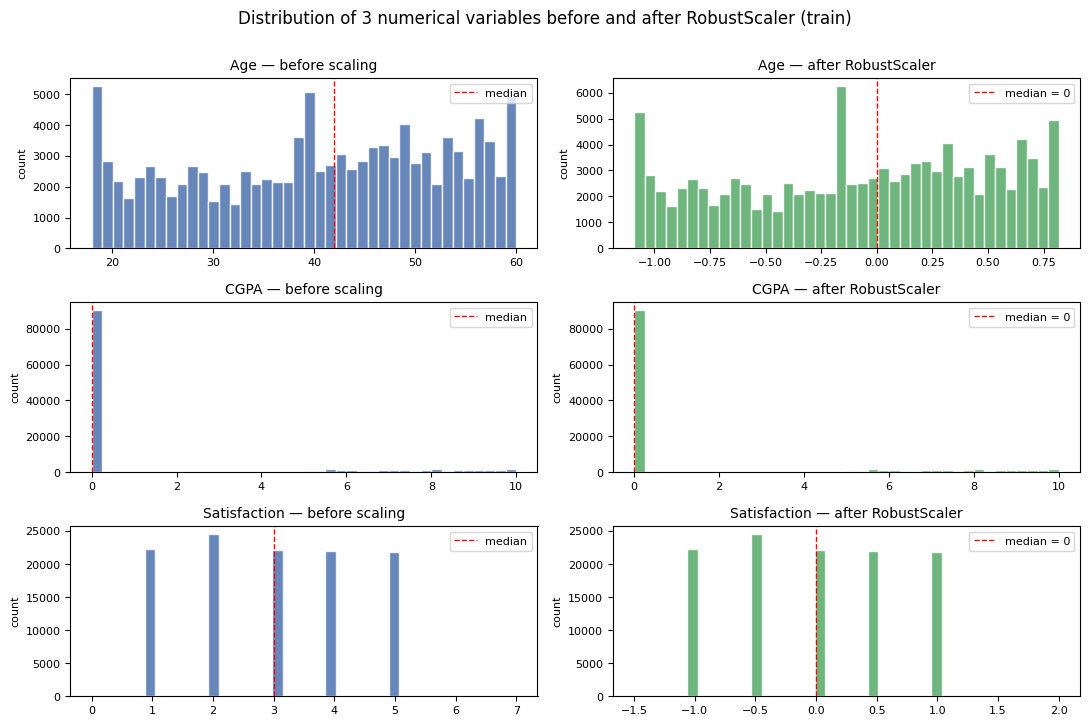

In [15]:
# 3.5.1 Histogram  Robust Scaling 

PLOT_COLS = SCALE_COLS[:4] 

n_cols = len(PLOT_COLS)
fig, axes = plt.subplots(n_cols, 2, figsize=(11, 2.4 * n_cols))

for i, col in enumerate(PLOT_COLS):
    ax_before, ax_after = axes[i, 0], axes[i, 1]

    ax_before.hist(train_pre_scale[col], bins=40, color="#4C72B0",
                   edgecolor="white", alpha=0.85)
    ax_before.set_title(f"{col} — before scaling", fontsize=10)
    ax_before.axvline(train_pre_scale[col].median(), color="red",
                      linestyle="--", linewidth=1, label="median")
    ax_before.legend(fontsize=8)

    ax_after.hist(train[col], bins=40, color="#55A868",
                  edgecolor="white", alpha=0.85)
    ax_after.set_title(f"{col} — after RobustScaler", fontsize=10)
    ax_after.axvline(0, color="red", linestyle="--", linewidth=1, label="median = 0")
    ax_after.legend(fontsize=8)

    for ax in (ax_before, ax_after):
        ax.set_ylabel("count", fontsize=8)
        ax.tick_params(labelsize=8)

fig.suptitle(f"Distribution of {n_cols} numerical variables before and after RobustScaler (train)",
             fontsize=12, y=1.002)
plt.tight_layout()

plt.show()

---
### 3.6 Post-Encoding Check
Observation from Correlation Plot: The newly engineered `Stress_Score` and unified `Pressure` variables show strong positive correlations with `Depression`, validating our feature merging strategy. Conversely, `Age` and `Is_Working_Professional` show strong negative correlations, suggesting that younger individuals (students) in this dataset are at higher risk.

In [16]:
print("Shape ")
print(f"  Train : {train.shape}")
print(f"  Test  : {test.shape}")
assert train.shape[1] == test.shape[1], "Column count mismatch between train and test!"
assert list(train.columns) == list(test.columns), "Column order mismatch!"

print("\nMissing values (train) ")
nulls = train.isnull().sum()
print(nulls[nulls > 0].to_string() if nulls.any() else "  None — clean.")

print("\nMissing values (test) ")
nulls_t = test.isnull().sum()
print(nulls_t[nulls_t > 0].to_string() if nulls_t.any() else "  None — clean.")

print("\nNear-zero-variance binary columns (<0.5% or >99.5% positive rate) ──")
bin_cols = [c for c in train.columns
            if set(train[c].dropna().unique()).issubset({0, 1})]
low_var  = [(c, f"{train[c].mean():.3%}") for c in bin_cols
            if train[c].mean() < 0.005 or train[c].mean() > 0.995]
print(low_var if low_var else "  None found.")

print("\ndtypes ")
print(train.dtypes.value_counts())

Shape 
  Train : (112552, 39)
  Test  : (28138, 39)

Missing values (train) 
  None — clean.

Missing values (test) 
  None — clean.

Near-zero-variance binary columns (<0.5% or >99.5% positive rate) ──
  None found.

dtypes 
int64      34
float64     5
Name: count, dtype: int64


In [17]:
print("Final column inventory:")
for i, c in enumerate(train.columns, 1):
    print(f"  {i:3d}. {c}")

Final column inventory:
    1. Gender
    2. Age
    3. Is_Working_Professional
    4. CGPA
    5. Sleep Duration
    6. Dietary Habits
    7. Degree
    8. Suicidal_Thoughts
    9. Work/Study Hours
   10. Family History of Mental Illness
   11. Depression
   12. Satisfaction
   13. Stress_Score
   14. Sleep_Risk_Flag
   15. City_Agra
   16. City_Ahmedabad
   17. City_Indore
   18. City_Kalyan
   19. City_Kolkata
   20. City_Ludhiana
   21. City_Meerut
   22. City_Mumbai
   23. City_Patna
   24. City_Pune
   25. City_Rajkot
   26. City_Srinagar
   27. City_Surat
   28. City_Vasai-Virar
   29. City_Visakhapatnam
   30. Prof_Architect
   31. Prof_Business Analyst
   32. Prof_Consultant
   33. Prof_Content Writer
   34. Prof_Doctor
   35. Prof_HR Manager
   36. Prof_Pharmacist
   37. Prof_Student
   38. Prof_Teacher
   39. Prof_Unknown


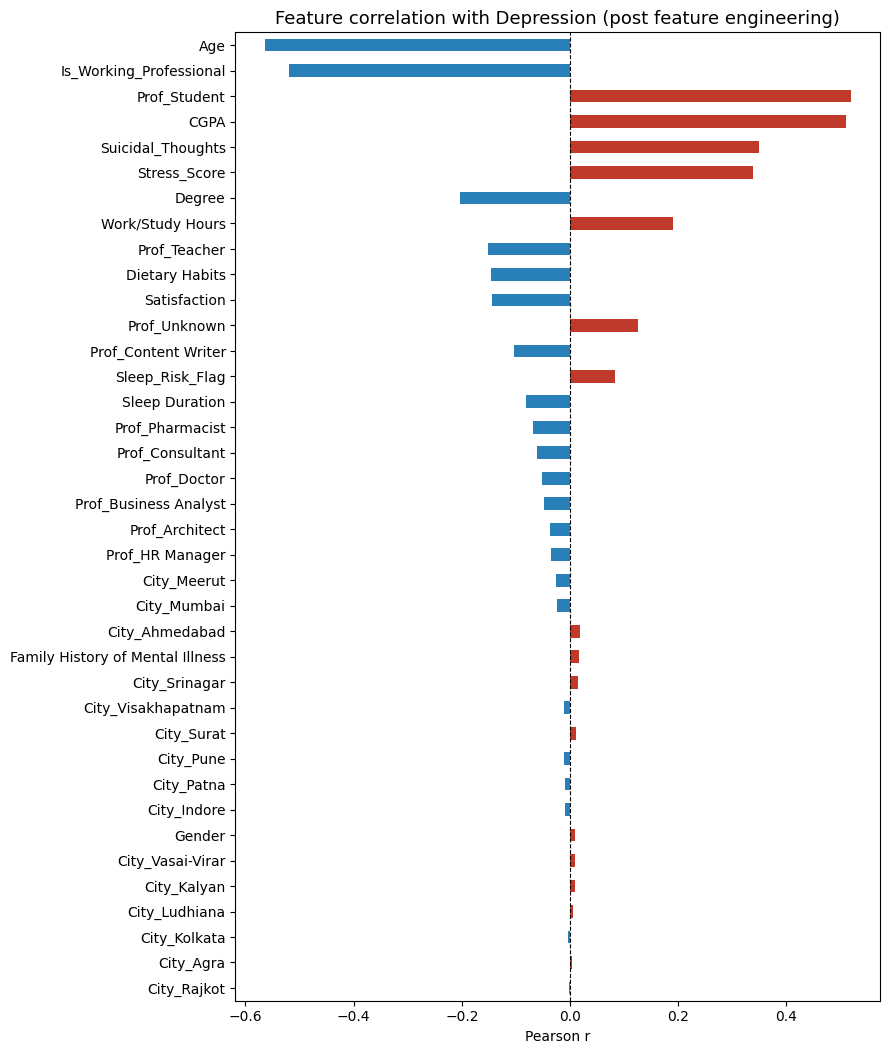

Saved: ..\artifacts\feature_correlation.png


In [ ]:
# Correlation with target
TARGET   = "Depression"
num_cols = [c for c in train.select_dtypes(include="number").columns if c != TARGET]

corr = (
    train[num_cols + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(9, max(6, len(corr) * 0.28)))
colors = ["#c0392b" if v > 0 else "#2980b9" for v in corr]
corr.plot(kind="barh", ax=ax, color=colors, edgecolor="none")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Feature correlation with Depression (post feature engineering)", fontsize=13)
ax.set_xlabel("Pearson r")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "feature_correlation.png", dpi=150)
plt.show()
print("Saved:", ARTIFACT_DIR / "feature_correlation.png")

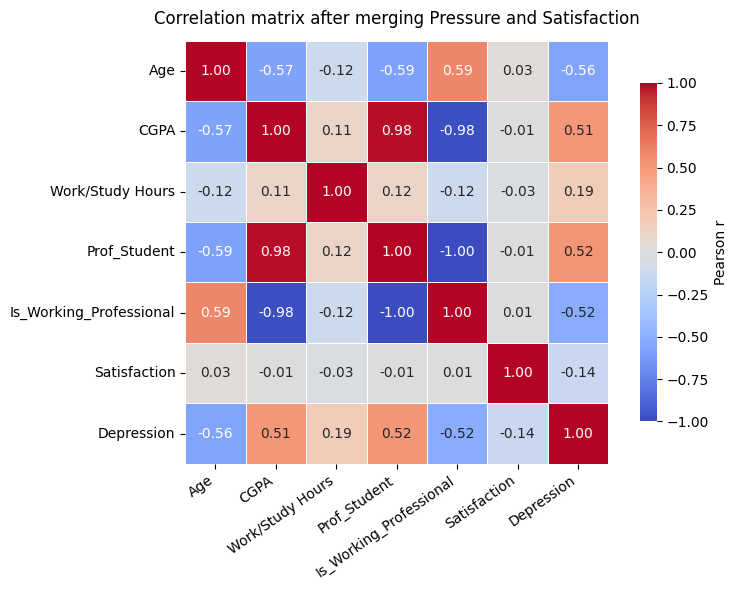


Top variables correlated with Depression:
Age                        0.564358
Is_Working_Professional    0.519750
Prof_Student               0.518883
CGPA                       0.510436
Work/Study Hours           0.191059
Satisfaction               0.144065
Name: Depression, dtype: float64


In [19]:
numeric_cols = ["Age", "CGPA", "Work/Study Hours", "Prof_Student",
                "Is_Working_Professional", "Satisfaction", "Depression"]

corr_post_merge = train[numeric_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_post_merge,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    ax=ax,
)
ax.set_title("Correlation matrix after merging Pressure and Satisfaction", fontsize=12, pad=12)
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nTop variables correlated with Depression:")
print(
    corr_post_merge["Depression"]
    .drop("Depression")
    .abs()
    .sort_values(ascending=False)
)

---
### 3.7 Save Engineered Datasets

In [20]:
train.to_csv(TRAIN_OUT, index=False)
test.to_csv(TEST_OUT,   index=False)

print(f"Saved  fe_train.csv  ->  {train.shape}")
print(f"Saved  fe_test.csv   ->  {test.shape}")
print("\nAll artifacts in", ARTIFACT_DIR, ":")
for f in sorted(ARTIFACT_DIR.iterdir()):
    print(f"  {f.name}")

Saved  fe_train.csv  ->  (112552, 39)
Saved  fe_test.csv   ->  (28138, 39)

All artifacts in ..\artifacts :
  confusion_matrices.png
  confusion_matrices_2x2.png
  correlation_post_merge.png
  encoding_dimension_table.csv
  feature_correlation.png
  kfold_target_encoding.pkl
  lr_coefficients.png
  lr_model.pkl
  ohe_categories.pkl
  ordinal_maps.pkl
  rf_feature_importance.png
  rf_model.pkl
  robust_scaler.pkl
  roc_curves.png
  scaling_before_after_hist.png
  scaling_before_after_hist_top4.png
  shap_bar.png
  shap_beeswarm.png
  xgb_best.pkl
  xgb_default.pkl
  xgb_feature_importance.png
  xgb_gridsearch_cv_results.csv
